In [ ]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt

In [ ]:
from google.colab import files
uploaded=files.upload()

Saving abalone (1).csv to abalone (1) (1).csv


In [ ]:
df = pd.read_csv("abalone (1).csv")

In [ ]:
df.head()

,Sex,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


In [ ]:
df.describe()

,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
count,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000
mean,0.523992,0.407881,0.139516,0.828742,0.359367,0.180594,0.238831,9.933684
std,0.120093,0.099240,0.041827,0.490389,0.221963,0.109614,0.139203,3.224169
min,0.075000,0.055000,0.000000,0.002000,0.001000,0.000500,0.001500,1.000000
25%,0.450000,0.350000,0.115000,0.441500,0.186000,0.093500,0.130000,8.000000
50%,0.545000,0.425000,0.140000,0.799500,0.336000,0.171000,0.234000,9.000000
75%,0.615000,0.480000,0.165000,1.153000,0.502000,0.253000,0.329000,11.000000
max,0.815000,0.650000,1.130000,2.825500,1.488000,0.760000,1.005000,29.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4177 entries, 0 to 4176
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sex             4177 non-null   object 
 1   Length          4177 non-null   float64
 2   Diameter        4177 non-null   float64
 3   Height          4177 non-null   float64
 4   Whole weight    4177 non-null   float64
 5   Shucked weight  4177 non-null   float64
 6   Viscera weight  4177 non-null   float64
 7   Shell weight    4177 non-null   float64
 8   Rings           4177 non-null   int64  
dtypes: float64(7), int64(1), object(1)
memory usage: 293.8+ KB


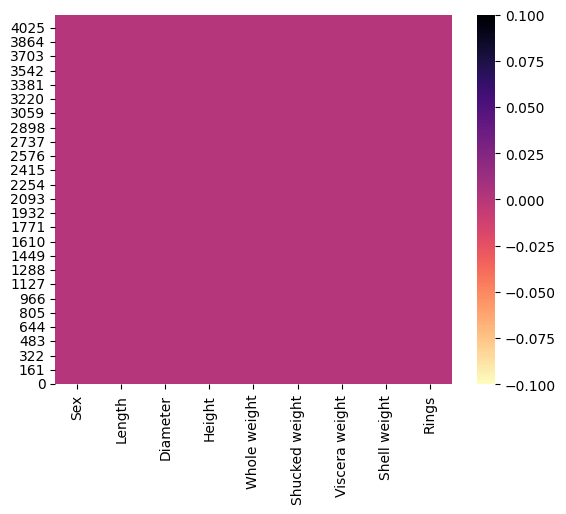

In [ ]:
sb.heatmap(df.isnull(), cmap = 'magma_r')
plt.gca().invert_yaxis()

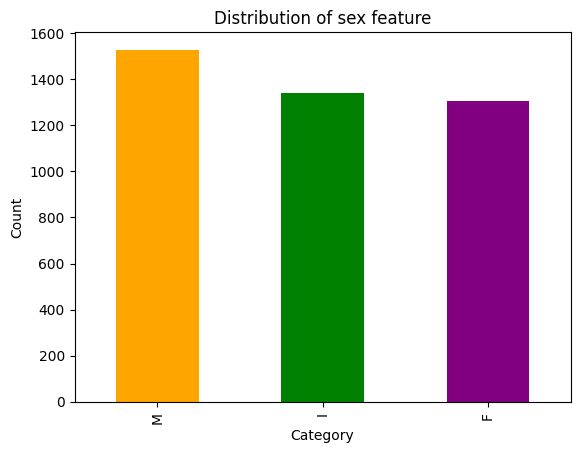

In [ ]:
df['Sex'].value_counts().plot(kind='bar',color=['orange','green','purple'])
plt.title('Distribution of sex feature')
plt.xlabel('Category')
plt.ylabel('Count')
plt.show()

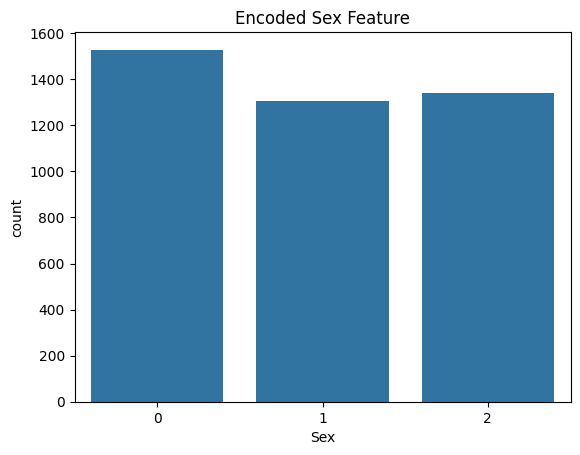

In [ ]:
df['Sex'] = df['Sex'].map({"M":0, "F":1, "I":2})
sb.countplot(x='Sex',data=df)
plt.title("Encoded Sex Feature")
plt.show()

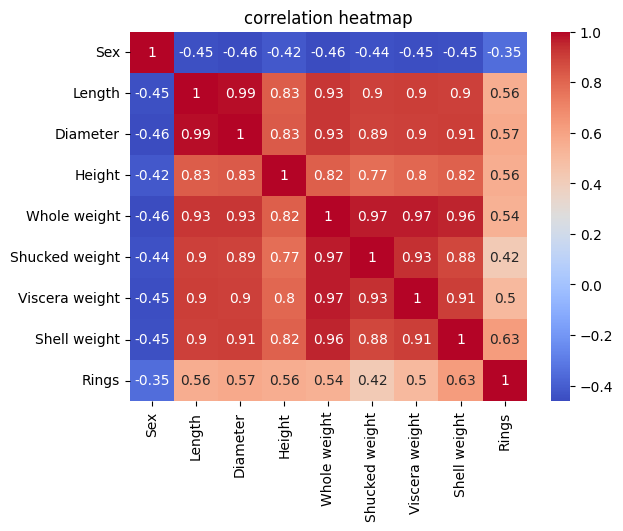

In [ ]:
corr=df.corr()
sb.heatmap(corr,annot=True,cmap='coolwarm')
plt.title('correlation heatmap')
plt.show()

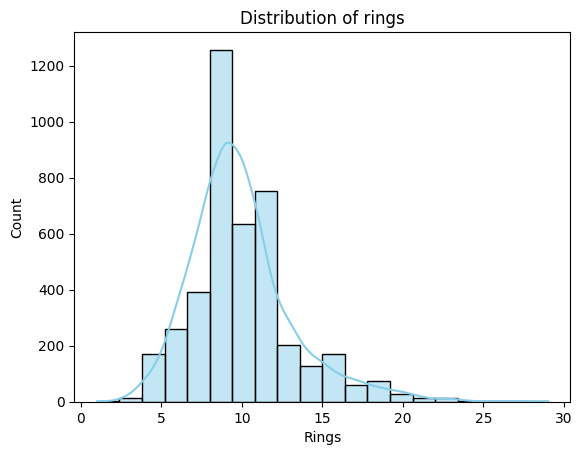

In [ ]:
sb.histplot(df['Rings'],bins=20,kde=True,color='skyblue')
plt.title('Distribution of rings')
plt.show()

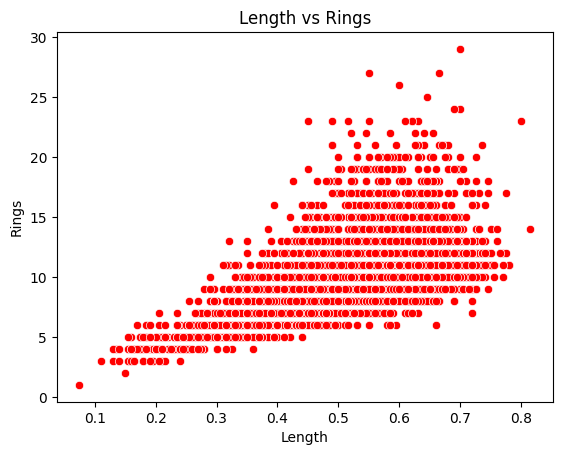

In [ ]:
sb.scatterplot(x='Length',y='Rings',color='red',data=df)
plt.title('Length vs Rings')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
X=df.drop('Rings',axis=1)
y=df['Rings']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=24)


In [ ]:
X.columns

Index(['Sex', 'Length', 'Diameter', 'Height', 'Whole weight', 'Shucked weight',
       'Viscera weight', 'Shell weight'],
      dtype='object')

In [ ]:
y.info()

<class 'pandas.core.series.Series'>
RangeIndex: 4177 entries, 0 to 4176
Series name: Rings
Non-Null Count  Dtype
--------------  -----
4177 non-null   int64
dtypes: int64(1)
memory usage: 32.8 KB


In [ ]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_train_scaled=sc.fit_transform(X_train)
X_test_scaled=sc.transform(X_test)

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

models = [
    ('Linear Regression', LinearRegression()),
    ('Ridge Regression', Ridge()),
    ('Decision Tree', DecisionTreeRegressor(random_state=42)),
    ('Random Forest', RandomForestRegressor(random_state=42))
]

In [ ]:
results = {}
for name, model in models:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    results[name] = r2
    print(f'{name}: MSE = {mse:.2f}, R2 = {r2:.2f}')

Linear Regression: MSE = 4.94, R2 = 0.50
Ridge Regression: MSE = 4.94, R2 = 0.50
Decision Tree: MSE = 8.22, R2 = 0.17
Random Forest: MSE = 4.67, R2 = 0.53


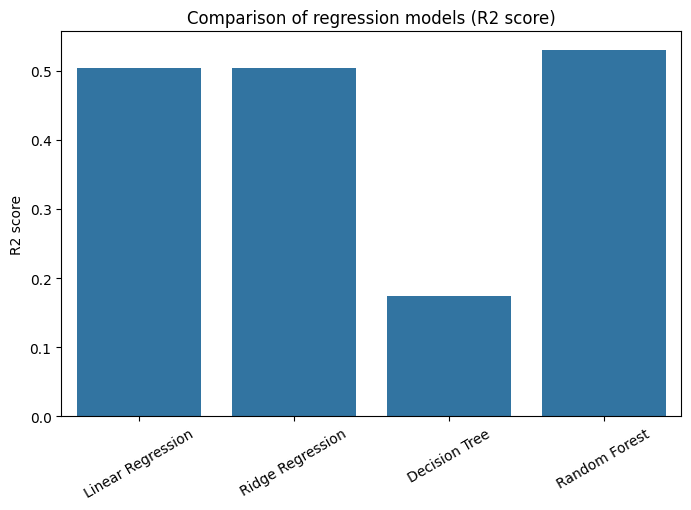

In [ ]:
plt.figure(figsize=(8,5))
sb.barplot(x=list(results.keys()),y=list(results.values()))
plt.title("Comparison of regression models (R2 score)")
plt.ylabel("R2 score")
plt.xticks(rotation=30)
plt.show()

In [ ]:
dtr=DecisionTreeRegressor()
dtr.fit(X_train,y_train)
y_pred=dtr.predict(X_test)
print("Decision Tree MSE:",mean_squared_error(y_test,y_pred))
print("Decision Tree R2:",r2_score(y_test,y_pred))

Decision Tree MSE: 8.357655502392344
Decision Tree R2: 0.1600395510188587


In [ ]:
rdm=RandomForestRegressor()
rdm.fit(X_train,y_train)
y_pred=dtr.predict(X_test)
print("Random forest MSE:",mean_squared_error(y_test,y_pred))
print("Random forest R2:",r2_score(y_test,y_pred))

Random forest MSE: 8.357655502392344
Random forest R2: 0.1600395510188587


In [ ]:
def prediction_age(Sex, Length, Diameter, Height, Whole_weight, Shucked_weight, Viscera_weight, Shell_weight):
    features = np.array([[Sex, Length, Diameter, Height, Whole_weight, Shucked_weight, Viscera_weight, Shell_weight]])
    pred = dtr.predict(features).reshape(1, -1)
    return pred[0]

In [ ]:
Sex = 2
Length = 0.6
Diameter = 0.45
Height = 0.15
Whole_weight = 1.2
Shucked_weight = 0.6
Viscera_weight = 0.3
Shell_weight = 0.4

prediction = prediction_age(Sex, Length, Diameter, Height, Whole_weight, Shucked_weight, Viscera_weight, Shell_weight)
print("Predicted Rings (Age):", prediction)

Predicted Rings (Age): [10.]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


In [ ]:
Sex = 2
Length = 0.1
Diameter = 0.40
Height = 0.15
Whole_weight = 1.6
Shucked_weight = 0.6
Viscera_weight = 0.4
Shell_weight = 0.4

prediction = prediction_age(Sex, Length, Diameter, Height, Whole_weight, Shucked_weight, Viscera_weight, Shell_weight)
print("Predicted Rings (Age):", prediction)

Predicted Rings (Age): [14.]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


In [ ]:
def prediction_age(Sex, Length, Diameter, Height, Whole_weight, Shucked_weight, Viscera_weight, Shell_weight):
    features = np.array([[Sex, Length, Diameter, Height, Whole_weight, Shucked_weight, Viscera_weight, Shell_weight]])
    pred = rdm.predict(features).reshape(1, -1)
    return pred[0]

In [ ]:
Sex = 2
Length = 0.1
Diameter = 0.40
Height = 0.15
Whole_weight = 1.6
Shucked_weight = 0.6
Viscera_weight = 0.4
Shell_weight = 0.4

prediction = prediction_age(Sex, Length, Diameter, Height, Whole_weight, Shucked_weight, Viscera_weight, Shell_weight)
print("Predicted Rings (Age):", prediction)

Predicted Rings (Age): [13.2]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [ ]:
Sex = 1
Length = 0.5
Diameter = 0.45
Height = 0.15
Whole_weight = 1.3
Shucked_weight = 0.6
Viscera_weight = 0.7
Shell_weight = 0.9

prediction = prediction_age(Sex, Length, Diameter, Height, Whole_weight, Shucked_weight, Viscera_weight, Shell_weight)
print("Predicted Rings (Age):", prediction)

Predicted Rings (Age): [18.11]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [ ]:
df.tail()

,Sex,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
4172,1,0.565,0.450,0.165,0.8870,0.3700,0.2390,0.2490,11
4173,0,0.590,0.440,0.135,0.9660,0.4390,0.2145,0.2605,10
4174,0,0.600,0.475,0.205,1.1760,0.5255,0.2875,0.3080,9
4175,1,0.625,0.485,0.150,1.0945,0.5310,0.2610,0.2960,10
4176,0,0.710,0.555,0.195,1.9485,0.9455,0.3765,0.4950,12


In [ ]:
Sex = 1
Length = 0.565
Diameter = 0.450
Height = 0.165
Whole_weight = 0.8870
Shucked_weight = 0.3700
Viscera_weight = 0.2390
Shell_weight = 0.2490

prediction = prediction_age(Sex, Length, Diameter, Height, Whole_weight, Shucked_weight, Viscera_weight, Shell_weight)
print("Predicted Rings (Age):", prediction)

Predicted Rings (Age): [10.78]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [ ]:
def prediction_age(Sex, Length, Diameter, Height, Whole_weight, Shucked_weight, Viscera_weight, Shell_weight):
    features = np.array([[Sex, Length, Diameter, Height, Whole_weight, Shucked_weight, Viscera_weight, Shell_weight]])
    pred = dtr.predict(features).reshape(1, -1)
    return pred[0]

In [ ]:
Sex = 1
Length = 0.565
Diameter = 0.450
Height = 0.165
Whole_weight = 0.8870
Shucked_weight = 0.3700
Viscera_weight = 0.2390
Shell_weight = 0.2490

prediction = prediction_age(Sex, Length, Diameter, Height, Whole_weight, Shucked_weight, Viscera_weight, Shell_weight)
print("Predicted Rings (Age):", prediction)

Predicted Rings (Age): [11.]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


In [ ]:
import pickle
pickle.dump(model, open("model.pkl", "wb"))